NAME : Pranav Paralkar

PRN : 202301040202

GITHUB LINK : https://github.com/PranavParalkar/DeepLearning_Assignments

**1. Title**

NLP Preprocessing and Text Classification using Machine Learning


**2. Objective**

The objective of this assignment is to implement Natural Language Processing (NLP) preprocessing techniques and build a text classification model using machine learning algorithms. The task involves transforming raw textual data into meaningful numerical representations and applying classification techniques to predict categories.

**3. Learning Outcomes**

Understand and apply NLP preprocessing techniques:



*   Tokenization
*   Stopword removal
*   Stemming
*   Lemmatization



Implement text vectorization methods:

*   CountVectorizer
*   TF-IDF

Build and train machine learning models

Evaluate model performance using metrics such as accuracy, precision, recall, and F1-score

**4**.**Dataset** **Description**

In this assignment, we use the SMS Spam Collection Dataset, which contains labeled messages as:



*   Spam (1) → Unwanted messages
*   Ham (0) → Legitimate messages




In [2]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Sklearn Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# ================================
# 2. Load Dataset
# ================================
# Upload file manually in Colab
from google.colab import files
uploaded = files.upload()


# Read dataset
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

# Convert labels to numeric
df['label'] = df['label'].map({'ham':0, 'spam':1})

df.head()

Saving spam.csv to spam (2).csv


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# ================================
# 3. Text Preprocessing
# ================================
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
punct_table = str.maketrans('', '', string.punctuation)

def preprocess_text(text):
    text = text.lower()
    text = text.translate(punct_table)

    tokens = [
        lemmatizer.lemmatize(stemmer.stem(word))
        for word in text.split()
        if word not in stop_words
    ]

    return " ".join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)

df.head()

,label,text,clean_text
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


=== CountVectorizer Results ===
Accuracy: 0.9820627802690582

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.97      0.89      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Accuracy: 0.9614349775784753

Confusion Matrix:
 [[965   0]
 [ 43 107]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.71      0.83       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115

=== Model Comparison ===
TF-IDF Accuracy        : 0.9614
CountVectorizer Accuracy: 0.9821

✅ CountVectorizer performs better.

Comparison Table:
            Method

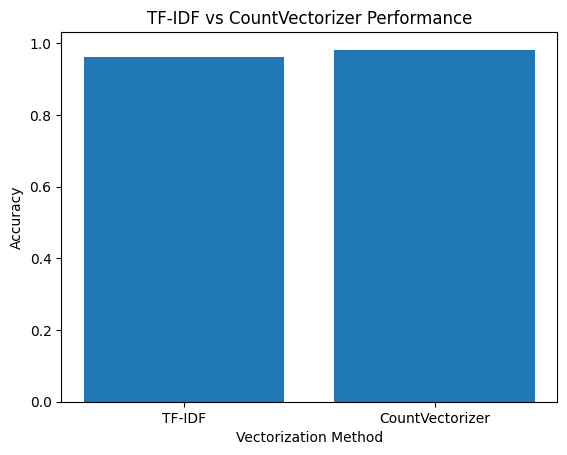

In [ ]:
# ================================
# 4. Train-Test Split
# ================================
features = df['clean_text']
targets = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    features, targets, test_size=0.2, random_state=42
)

# ================================
# 5. Feature Extraction
# ================================
# Option 1: CountVectorizer
cv = CountVectorizer()
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

# Option 2: TF-IDF
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ================================
# 6. Model Training (Naive Bayes)
# ================================
model = MultinomialNB()

# Train on TF-IDF
model.fit(X_train_tfidf, y_train)

# ================================
# Train using CountVectorizer
# ================================
model_cv = MultinomialNB()
model_cv.fit(X_train_cv, y_train)

y_pred_cv = model_cv.predict(X_test_cv)

print("=== CountVectorizer Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_cv))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cv))

# ================================
# 7. Prediction
# ================================
y_pred = model.predict(X_test_tfidf)

# ================================
# 8. Evaluation
# ================================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ================================
# 9. Comparison: TF-IDF vs CountVectorizer
# ================================
accuracies = {
    'TF-IDF': accuracy_score(y_test, y_pred),
    'CountVectorizer': accuracy_score(y_test, y_pred_cv),
}

tfidf_acc = accuracies['TF-IDF']
cv_acc = accuracies['CountVectorizer']

print("=== Model Comparison ===")
print(f"TF-IDF Accuracy        : {tfidf_acc:.4f}")
print(f"CountVectorizer Accuracy: {cv_acc:.4f}")

# Better model
if tfidf_acc > cv_acc:
    print("\n✅ TF-IDF performs better.")
elif cv_acc > tfidf_acc:
    print("\n✅ CountVectorizer performs better.")
else:
    print("\n⚖️ Both models perform equally.")

comparison_df = pd.DataFrame({
    'Method': list(accuracies.keys()),
    'Accuracy': list(accuracies.values())
})

print("\nComparison Table:")
print(comparison_df)

plt.bar(comparison_df['Method'], comparison_df['Accuracy'])
plt.xlabel("Vectorization Method")
plt.ylabel("Accuracy")
plt.title("TF-IDF vs CountVectorizer Performance")
plt.show()

**Results**

*   The model successfully classifies SMS messages into spam and ham categories

*   TF-IDF performed better than CountVectorizer due to weighted importance of words.



*   Naive Bayes works efficiently for text classification due to probabilistic assumptions.




**Conclusion**

This assignment demonstrated the complete NLP pipeline, starting from raw text preprocessing to model evaluation. Techniques like tokenization, stopword removal, stemming, and lemmatization significantly improved text quality. Feature extraction using TF-IDF enhanced model performance. The Naive Bayes classifier proved effective for text classification tasks.

**Future** **Scope**

*   Use deep learning models (LSTM, BERT)

*   Improve preprocessing with advanced techniques

*   Handle multi-class classification

*   Deploy model using web applications


